# **EfficientNet Pre-trained Binary Model with Upsampled Transformed Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. <br>
For this, transformed/pre-processed images were used and the class imbalance was fixed. <br>
The transformed images are the ones used on the `02_efficient_net_pretrained_transformations.ipynb`. <br>
The class imbalance was fixed using `label_cropper.py` and `augmenter_routine.ipynb`.

## Libraries

In [1]:
# Libraries
import pandas as pd

from deep.constants import METADATA_FILE, ROOT, SEED
from deep.models.model_runs import run_binary_model
from deep.models.model_defs import efficient_net

2025-04-26 19:04:29.071628: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 19:04:29.088423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-26 19:04:29.106316: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-26 19:04:29.110754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-26 19:04:29.127053: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing and Modelling

In [4]:
# Define seeds and path
binary_baseline_path = f"{ROOT}/models/binary_scores.json"

In [5]:
# import os
# import re

# from constants import PROCESSED_DIR

# folder_path = PROCESSED_DIR

# for filename in os.listdir(folder_path):
#     if re.search(r'[a-zA-Z]', filename[:-4]):
#         if not filename[:-4].endswith('_noanimalcrop'):
#             file_path = os.path.join(folder_path, filename)
#             if os.path.isfile(file_path):
#                 os.remove(file_path)
#                 print(f"Deleted: {file_path}")

In [6]:
# # DISCLAIMER: Ensure the augmenter_routine.ipynb notebook has the following configuration values:
#     # label = "is_animal"
#     # min_sample = 10000
#     # target_ratio = 1.0
#     # output_name = "is_animal_upsample_map"
# # and the third code cell has the concat command uncommented!

# # Create upsamples images
# notebook_path = f'"{ROOT}/notebooks/preprocess_routine/augmenter_routine.ipynb"'
# %run $notebook_path

In [7]:
# from constants import METADATA_DIR
# from models.aux_funcs import split_data


# # Split the data
# train_df, val_df, test_df = split_data(data, 'is_animal', 20)

# cropped = pd.read_csv(f'{METADATA_DIR}/cropped_labels.csv')
# upsampled = pd.read_csv(f'{METADATA_DIR}/is_animal_upsample_map.csv')



In [8]:
# # Filter upsample based on the images on the train set

# # Upsampled images from crops
# aux_df1 = upsampled[upsampled['file_path'].str.contains('noanimalcrop', na=False)]

# # Upsampled images from train
# # Exclude the cropped images first
# temp = upsampled[~upsampled['file_path'].isin(aux_df1['file_path'])]

# # Filter to only rare_species_id in train_df
# aux_df2 = temp[temp['rare_species_id'].isin(train_df['rare_species_id'])]

In [9]:
# upsampled = pd.concat([
#     aux_df1
#     ,aux_df2
# ], ignore_index=True
# , axis=0)

In [10]:
# # Add the new metadata to train_df
# train_df = pd.concat([
#     train_df
#     ,cropped
#     ,upsampled
# ], ignore_index=True
# , axis=0
# )

### Raw Model

I0000 00:00:1745682421.797243   34669 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745682421.836668   34669 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745682421.837081   34669 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745682421.838136   34669 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9449213147163391
Found 17348 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


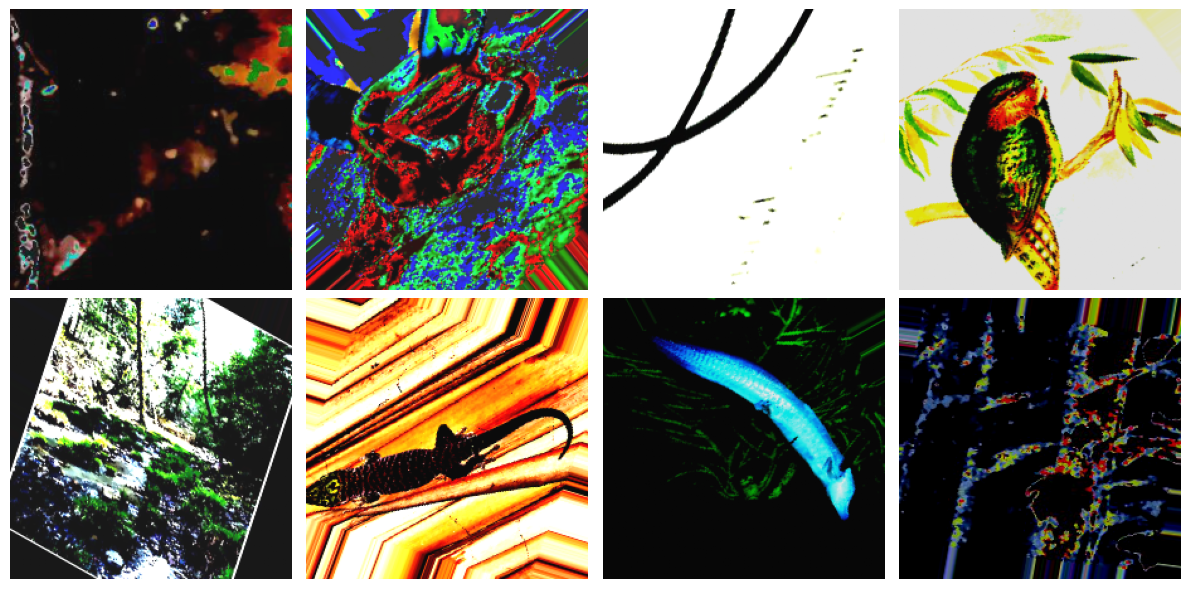

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745682450.427153   34724 service.cc:146] XLA service 0x751f740034a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745682450.427177   34724 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-26 16:47:31.127096: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-26 16:47:33.706354: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-26 16:47:45.068052: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-26 16:47:53.846144: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allo

131/272 ━━━━━━━━━━━━━━━━━━━━ 7:52 3s/step - accuracy: 0.6048 - auc: 0.6220 - loss: 0.6705 - precision: 0.5604 - recall: 0.4674

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


272/272 ━━━━━━━━━━━━━━━━━━━━ 1070s 4s/step - accuracy: 0.6138 - auc: 0.6389 - loss: 0.6617 - precision: 0.5780 - recall: 0.4557 - val_accuracy: 0.9333 - val_auc: 0.7447 - val_loss: 0.2516 - val_precision: 0.9361 - val_recall: 0.9963 - learning_rate: 0.0010
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 969s 4s/step - accuracy: 0.6367 - auc: 0.6738 - loss: 0.6417 - precision: 0.6138 - recall: 0.4318 - val_accuracy: 0.9291 - val_auc: 0.7459 - val_loss: 0.2333 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 977s 4s/step - accuracy: 0.6315 - auc: 0.6754 - loss: 0.6433 - precision: 0.6139 - recall: 0.4482 - val_accuracy: 0.0709 - val_auc: 0.7490 - val_loss: 1.6909 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6396 - auc: 0.6752 - loss: 0.6419 - precision: 0.6213 - recall: 0.4542
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000

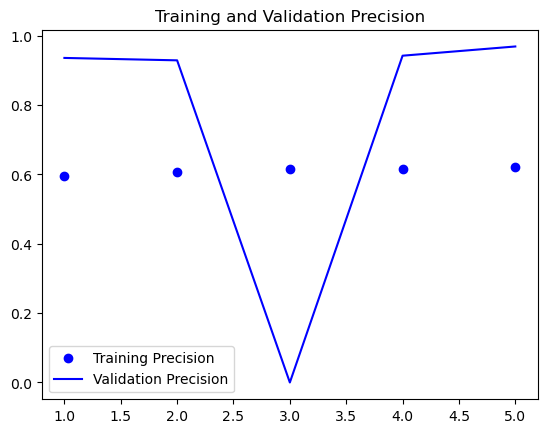

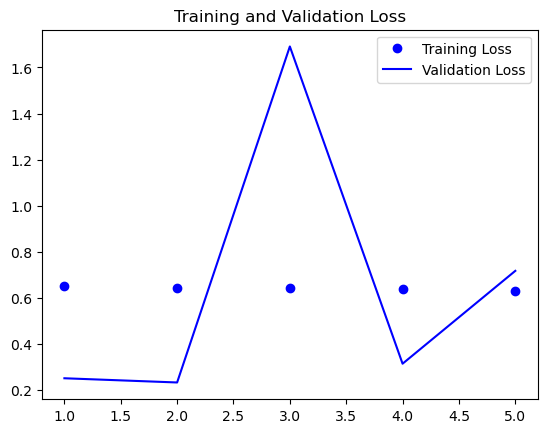

Current model not better than baseline


In [11]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsample'
)

This model using the transformed and upsampled images proved to be underfitting the training data. <br>
We will, however, test if adding regularization and/or the dropout layer will improve the underfitting and the model performance vis the baseline.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

2025-04-26 19:04:34.635812: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-04-26 19:04:34.635883: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: shadybea
2025-04-26 19:04:34.635889: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: shadybea
2025-04-26 19:04:34.636143: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 550.120.0
2025-04-26 19:04:34.636194: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.120.0
2025-04-26 19:04:34.636201: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:249] kernel version seems to match DSO: 550.120.0


Loaded baseline score: 0.9449213147163391
Found 17348 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


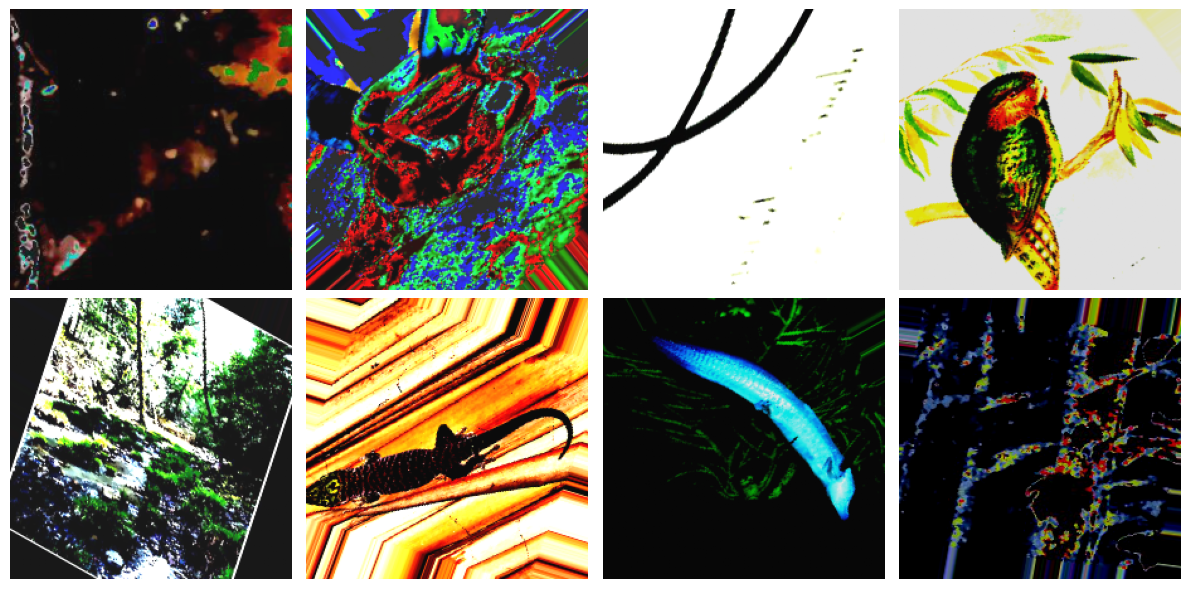

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
244/272 ━━━━━━━━━━━━━━━━━━━━ 1:54 4s/step - accuracy: 0.5941 - auc: 0.6202 - loss: 0.7553 - precision: 0.5560 - recall: 0.3921

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


272/272 ━━━━━━━━━━━━━━━━━━━━ 1245s 5s/step - accuracy: 0.5950 - auc: 0.6222 - loss: 0.7512 - precision: 0.5595 - recall: 0.3821 - val_accuracy: 0.9291 - val_auc: 0.7324 - val_loss: 0.2891 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1228s 5s/step - accuracy: 0.6086 - auc: 0.6498 - loss: 0.6661 - precision: 0.6036 - recall: 0.2854 - val_accuracy: 0.0716 - val_auc: 0.7450 - val_loss: 1.0068 - val_precision: 1.0000 - val_recall: 7.4794e-04 - learning_rate: 0.0010
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6284 - auc: 0.6740 - loss: 0.6523 - precision: 0.6350 - recall: 0.3433
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
272/272 ━━━━━━━━━━━━━━━━━━━━ 1233s 5s/step - accuracy: 0.6284 - auc: 0.6740 - loss: 0.6522 - precision: 0.6349 - recall: 0.3434 - val_accuracy: 0.8735 - val_auc: 0.7428 - val_loss: 0.4781 - val_precision: 0.9508 - val_recall: 0.9110 - learning_rate: 0.0010
Ep

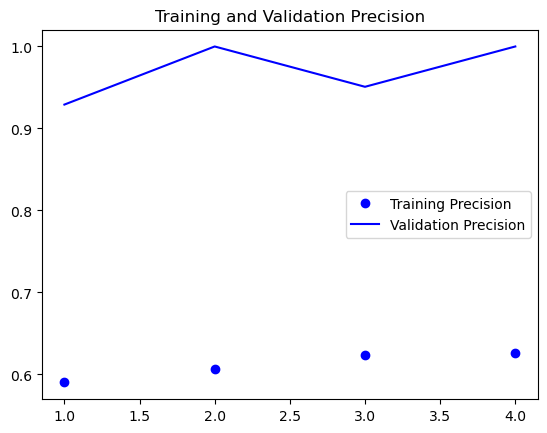

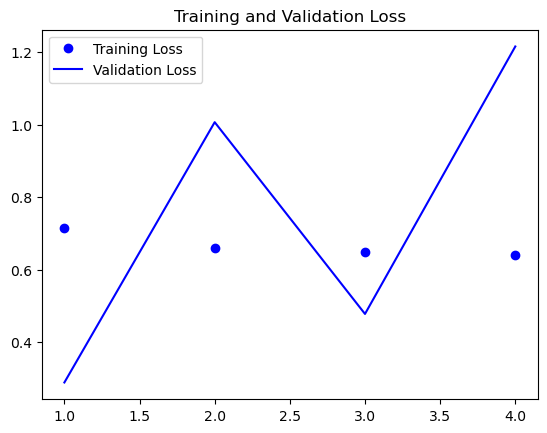

Current model not better than baseline


In [11]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsample'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9449213147163391
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


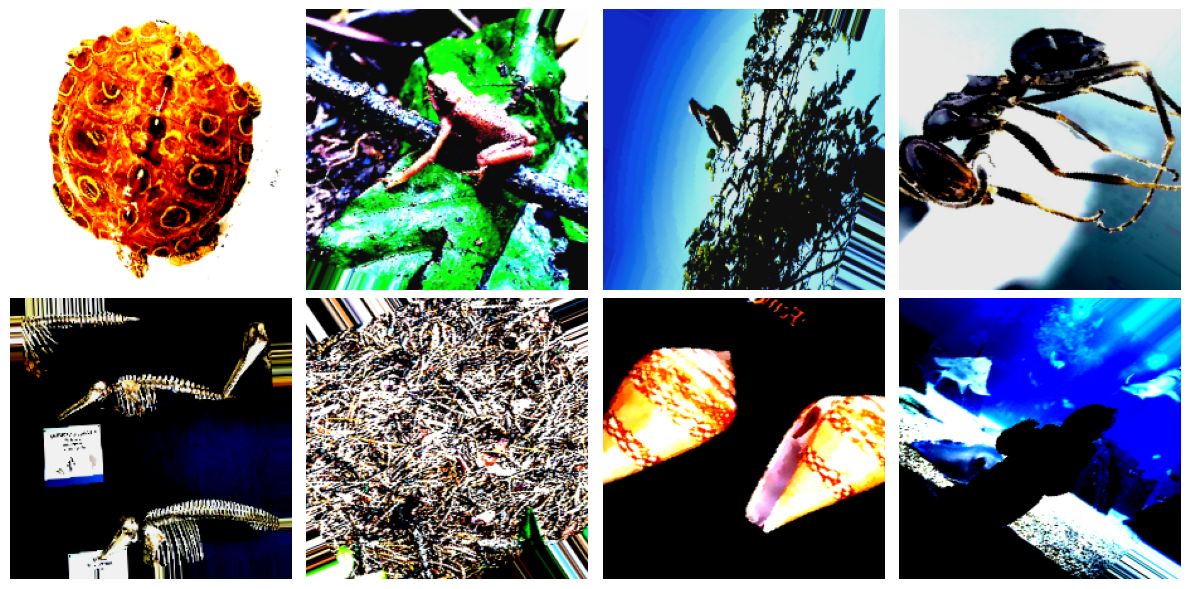

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
115/128 ━━━━━━━━━━━━━━━━━━━━ 1:09 5s/step - accuracy: 0.6490 - auc_1: 0.5228 - loss: 0.6643 - precision: 0.9347 - recall: 0.6701

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 820s 6s/step - accuracy: 0.6623 - auc_1: 0.5247 - loss: 0.6493 - precision: 0.9347 - recall: 0.6854 - val_accuracy: 0.0883 - val_auc_1: 0.7698 - val_loss: 0.9620 - val_precision: 1.0000 - val_recall: 0.0187 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 787s 6s/step - accuracy: 0.9265 - auc_1: 0.5999 - loss: 0.2753 - precision: 0.9348 - recall: 0.9900 - val_accuracy: 0.9291 - val_auc_1: 0.6817 - val_loss: 0.2913 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 784s 6s/step - accuracy: 0.9286 - auc_1: 0.5841 - loss: 0.2563 - precision: 0.9293 - recall: 0.9991 - val_accuracy: 0.9291 - val_auc_1: 0.7283 - val_loss: 0.2644 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 783s 6s/step - accuracy: 0.9287 - auc_1: 0.6186 - loss: 0.2538 - precision: 0.9298 - recall: 0.9985 - val_accuracy: 0.9291 - val_auc_1: 0.6157 - val_loss: 0.4

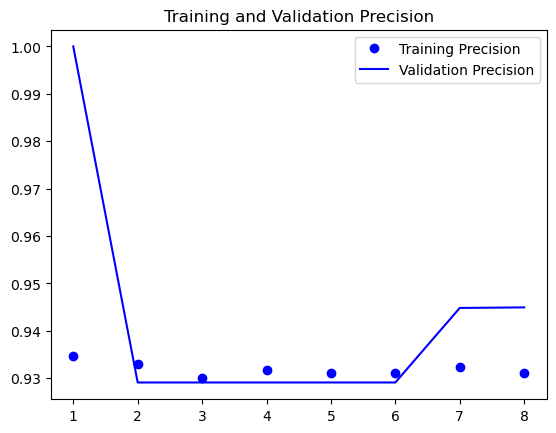

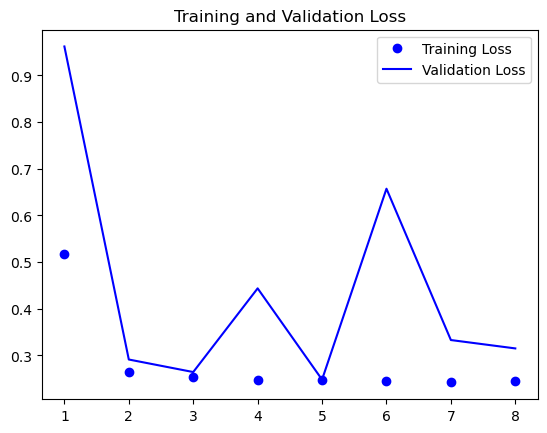

Current model not better than baseline


In [12]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
)

The dropout layer did not improve the model.

Now, we will attempt to fix the class imbalance based on the transformed images and recheck the model.